In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
sns.set_style("whitegrid")

In [8]:
products_df = pd.read_csv("../data/product_info.csv")

In [9]:
customers_df = pd.read_csv("../data/customer_info.csv")

In [11]:
sales_df = pd.read_csv("../data/sales_data.csv")

In [12]:
sales_df.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,06-07-2025,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,06-07-2025,DELAYED,credit card,North,0.00
2,O202644,C00492,P0011,1,29.68,07-07-2025,delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,08-07-2025,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,08-07-2025,DELAYED,Credit Card,West,0.20


In [13]:
products_df.head()

,product_id,product_name,category,launch_date,base_price,supplier_code
0,P0001,Storage Product 39,Storage,11-03-25,15.88,S339
1,P0002,Cleaning Product 82,Cleaning,18-08-24,34.23,S974
2,P0003,Cleaning Product 85,Cleaning,15-07-24,7.92,S745
3,P0004,Kitchen Product 82,Kitchen,19-04-25,9.13,S589
4,P0005,Personal Care Product 1,Personal Care,20-10-24,31.10,S559


In [14]:
customers_df.head()

,customer_id,email,signup_date,gender,region,loyalty_tier
0,C00001,shaneramirez@gmail.com,26-04-25,Male,Central,Silver
1,C00002,jpeterson@bernard.com,11-08-24,Female,Central,gold
2,C00003,howardmaurice@yahoo.com,15-05-25,male,Central,gold
3,C00004,yherrera@arnold.org,14-06-25,FEMALE,Central,GOLD
4,C00005,janetwilliams@gmail.com,02-05-25,Male,West,bronze


In [15]:
#standardising text columns in sales product and customer tables
sales_df['delivery_status'] = (
    sales_df['delivery_status']
    .str.strip()
    .str.title()
)

sales_df['region'] = sales_df['region'].str.strip().str.title()
sales_df['payment_method'] = sales_df['payment_method'].str.strip().str.title()

In [16]:
products_df['category'] = products_df['category'].str.strip().str.title()

In [17]:
customers_df['gender'] = customers_df['gender'].str.strip().str.title()
customers_df['loyalty_tier'] = customers_df['loyalty_tier'].str.strip().str.title()
customers_df['region'] = customers_df['region'].str.strip().str.title()

In [18]:
#convert date columns
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'], errors='coerce')
products_df['launch_date'] = pd.to_datetime(products_df['launch_date'], errors='coerce')
customers_df['signup_date'] = pd.to_datetime(customers_df['signup_date'], errors='coerce')

C:\Users\Salfil\AppData\Local\Temp\ipykernel_122920\4270402712.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  products_df['launch_date'] = pd.to_datetime(products_df['launch_date'], errors='coerce')
C:\Users\Salfil\AppData\Local\Temp\ipykernel_122920\4270402712.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customers_df['signup_date'] = pd.to_datetime(customers_df['signup_date'], errors='coerce')


In [19]:
sales_df.isnull().sum()
products_df.isnull().sum()
customers_df.isnull().sum()

customer_id     3
email           6
signup_date     4
gender          4
region          3
loyalty_tier    2
dtype: int64

In [22]:
#fill missing values
sales_df['discount_applied'] = sales_df['discount_applied'].fillna(0.0)
sales_df['region'] = sales_df['region'].fillna("Unknown")

customers_df['region'] = customers_df['region'].fillna("Unknown")
customers_df['loyalty_tier'] = customers_df['loyalty_tier'].fillna("Unknown")

In [21]:
customers_df['email'] = customers_df['email'].fillna("Unknown")

In [23]:
#Drop duplicates
sales_df = sales_df.drop_duplicates(subset='order_id')
products_df = products_df.drop_duplicates(subset='product_id')
customers_df = customers_df.drop_duplicates(subset='customer_id')

In [24]:
# convert dates 
sales_df['order_date'] = pd.to_datetime(
    sales_df['order_date'],
    format='%d/%m/%Y',
    errors='coerce'
)

products_df['launch_date'] = pd.to_datetime(
    products_df['launch_date'],
    format='%d/%m/%Y',
    errors='coerce'
)

customers_df['signup_date'] = pd.to_datetime(
    customers_df['signup_date'],
    format='%d/%m/%Y',
    errors='coerce'
)

In [26]:
sales_df[['quantity', 'unit_price', 'discount_applied']].dtypes

quantity             object
unit_price          float64
discount_applied    float64
dtype: object

In [27]:
numeric_cols = ['quantity', 'unit_price', 'discount_applied']

for col in numeric_cols:
    sales_df[col] = pd.to_numeric(sales_df[col], errors='coerce')

In [28]:
sales_df[numeric_cols].dtypes

quantity            float64
unit_price          float64
discount_applied    float64
dtype: object

In [29]:
# Merge sales_data with product_info using product_id 
merged_df = sales_df.merge(
    products_df,
    on='product_id',
    how='left'
)

In [30]:
#Merge the result with customer_info using customer_id 
merged_df = merged_df.merge(
    customers_df,
    on='customer_id',
    how='left'
)

In [31]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2998 entries, 0 to 2997
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2997 non-null   object        
 1   customer_id       2996 non-null   object        
 2   product_id        2993 non-null   object        
 3   quantity          2993 non-null   float64       
 4   unit_price        2997 non-null   float64       
 5   order_date        1180 non-null   datetime64[ns]
 6   delivery_status   2995 non-null   object        
 7   payment_method    2995 non-null   object        
 8   region_x          2998 non-null   object        
 9   discount_applied  2998 non-null   float64       
 10  product_name      2993 non-null   object        
 11  category          2993 non-null   object        
 12  launch_date       2993 non-null   datetime64[ns]
 13  base_price        2993 non-null   float64       
 14  supplier_code     2993 n

In [32]:
merged_df.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region_x,discount_applied,product_name,category,launch_date,base_price,supplier_code,email,signup_date,gender,region_y,loyalty_tier
0,O966977,C00397,P0022,3.0,39.25,2025-06-07,Delivered,Paypal,Central,0.00,Cleaning Product 86,Cleaning,2024-04-10,19.77,S924,jacquelinemartin@mills-logan.com,2024-08-09,Female,North,Silver
1,O696648,C00236,P0023,5.0,18.92,2025-06-07,Delayed,Credit Card,North,0.00,Outdoors Product 32,Outdoors,2025-01-18,36.04,S907,georgeweber@morgan.com,2024-06-08,Other,North,Gold
2,O202644,C00492,P0011,1.0,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,Kitchen Product 53,Kitchen,2025-03-25,11.08,S645,lcook@walters-smith.com,2024-09-25,Male,Central,Gold
3,O501803,C00031,P0003,1.0,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745,smoore@gmail.com,2024-07-28,Femle,Central,Gold
4,O322242,C00495,P0016,1.0,47.62,2025-08-07,Delayed,Credit Card,West,0.20,Cleaning Product 53,Cleaning,2025-02-20,26.71,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Central,Gold


In [33]:
# revenue = quan4ty × unit_price × (1 - discount_applied) 
merged_df['revenue'] = (
    merged_df['quantity'] *
    merged_df['unit_price'] *
    (1 - merged_df['discount_applied'])
)

In [34]:
#order_week = ISO week from order_date
merged_df['order_week'] = merged_df['order_date'].dt.isocalendar().week

In [35]:
#price_band = Categorise unit price as Low (<£15), Medium (£15–30), High (>£30) 
merged_df['price_band'] = pd.cut(
    merged_df['unit_price'],
    bins=[0, 15, 30, np.inf],
    labels=['Low', 'Medium', 'High']
)

In [36]:
#days_to_order = Days between launch_date and order_date
merged_df['days_to_order'] = (
    merged_df['order_date'] - merged_df['launch_date']
).dt.days

In [37]:
#email_domain = Extract domain from email (e.g., gmail.com) 
merged_df['email_domain'] = merged_df['email'].str.split('@').str[-1]

In [38]:
#is_late = True if delivery_status is "Delayed" 
is_late = True if delivery_status is "Delayed" 

SyntaxError: expected 'else' after 'if' expression (2237311411.py, line 2)

In [39]:
# is_late = True if delivery_status is "Delayed" 
merged_df['is_late'] = merged_df['delivery_status'] == "Delayed"

In [43]:
#summary table: weekly revenue by region
weekly_revenue = (
    merged_df
    .groupby(['order_week', 'region_x'])['revenue']
    .sum()
    .reset_index()
)

In [102]:
weekly_revenue

,order_week,region_x,revenue
0,1,East,173.8310
1,1,North,20.7825
2,1,South,55.8790
3,1,West,325.3200
4,2,Central,2248.1720
...,...,...,...
86,50,Central,625.2405
87,50,East,339.4810
88,50,North,169.8785
89,50,South,160.9050


In [45]:
#Category performance
category_perf = (
    merged_df
    .groupby('category')
    .agg(
        revenue=('revenue', 'sum'),
        quantity=('quantity', 'sum'),
        avg_discount=('discount_applied', 'mean')
    )
)

In [46]:
category_perf.head()

,revenue,quantity,avg_discount
category,,,
Cleaning,93621.7840,3584.0,0.085685
Kitchen,33933.6760,1226.0,0.075622
Outdoors,40062.0680,1523.0,0.082150
Personal Care,24916.6365,902.0,0.086755
Storage,46931.4575,1730.0,0.080763


In [47]:
# Customer behaviour
merged_df['signup_month'] = merged_df['signup_date'].dt.to_period('M')

customer_behaviour = (
    merged_df
    .groupby(['loyalty_tier', 'signup_month'])['revenue']
    .sum()
)

In [48]:
customer_behaviour.head()

loyalty_tier  signup_month
Brnze         2024-07          513.4745
              2025-04          290.0715
Bronze        2024-01          478.6450
              2024-02         1843.8570
              2024-03         1142.6895
Name: revenue, dtype: float64

In [58]:
merged_df['loyalty_tier'].value_counts(dropna=False)

loyalty_tier
NaN       2968
Gold        13
Bronze      11
Silver       6
Name: count, dtype: int64

In [104]:
#Delivery performance
delivery_perf = (
    merged_df
    .groupby(['region_x', 'price_band'])['is_late']
    .mean()
)
delivery_perf

C:\Users\Salfil\AppData\Local\Temp\ipykernel_122920\1048834092.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['region_x', 'price_band'])['is_late']


region_x  price_band
Central   Low           0.380531
          Medium        0.391111
          High          0.393939
East      Low           0.416667
          Medium        0.421941
          High          0.409774
North     Low           0.383178
          Medium        0.439024
          High          0.361775
South     Low           0.329897
          Medium        0.361386
          High          0.420339
West      Low           0.389610
          Medium        0.351020
          High          0.381481
Name: is_late, dtype: float64

In [61]:
payment_pref = (
    merged_df
    .groupby(['loyalty_tier', 'payment_method'])
    .size()
    .unstack(fill_value=0)
)

In [106]:
payment_pref

payment_method,Bank Transfer,Credit Card,Paypal
loyalty_tier,,,
Bronze,2,5,4
Gold,3,6,4
Silver,0,6,0


In [103]:
delivery_perf

region_x  price_band
Central   Low           0.380531
          Medium        0.391111
          High          0.392453
East      Low           0.416667
          Medium        0.424370
          High          0.408240
North     Low           0.383178
          Medium        0.441176
          High          0.361775
Nrth      Low                NaN
          Medium        0.000000
          High               NaN
South     Low           0.336735
          Medium        0.361386
          High          0.418919
West      Low           0.389610
          Medium        0.351020
          High          0.381481
Name: is_late, dtype: float64

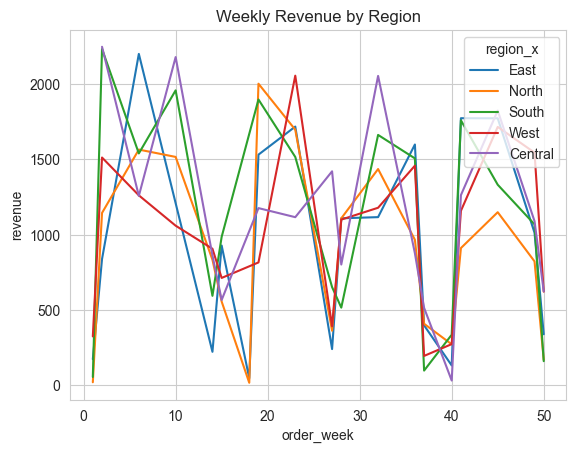

In [66]:
#visual exploration - weekly revenue by region
sns.lineplot(data=weekly_revenue, x='order_week', y='revenue', hue='region_x')
plt.title("Weekly Revenue by Region")
plt.show()

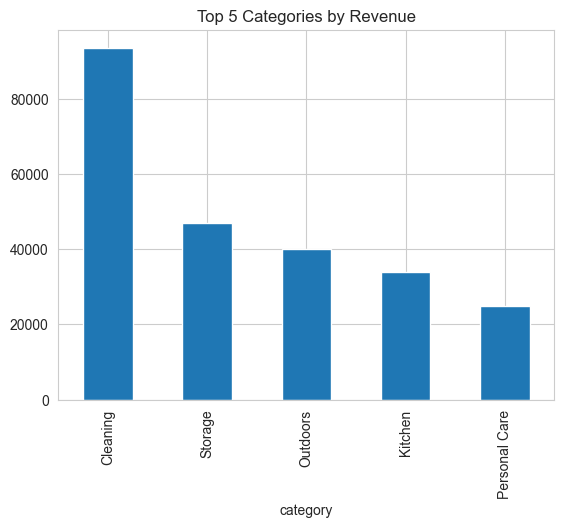

In [67]:
#top categories
category_perf.sort_values('revenue', ascending=False).head(5)['revenue'].plot(kind='bar')
plt.title("Top 5 Categories by Revenue")
plt.show()

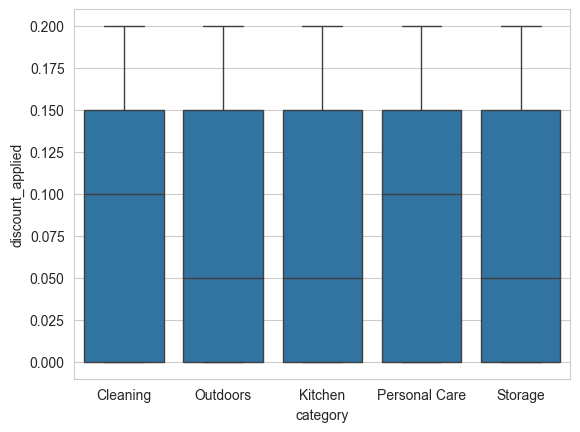

In [68]:
#quality vs discount
sns.boxplot(data=merged_df, x='category', y='discount_applied')
plt.show()

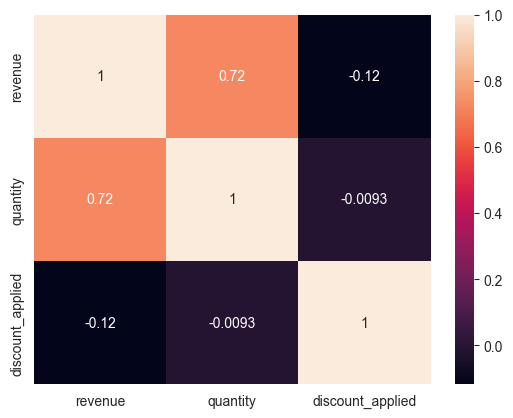

In [69]:
#coorelation heatmap of discount applied
sns.heatmap(
    merged_df[['revenue', 'quantity', 'discount_applied']].corr(),
    annot=True
)
plt.show()

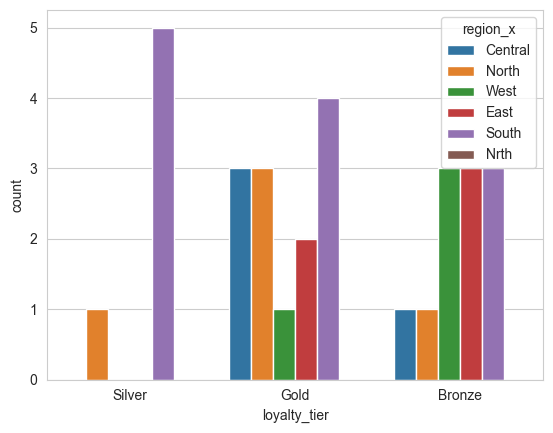

In [71]:
#orders by loyalty tier
sns.countplot(data=merged_df, x='loyalty_tier', hue='region_x')
plt.show()

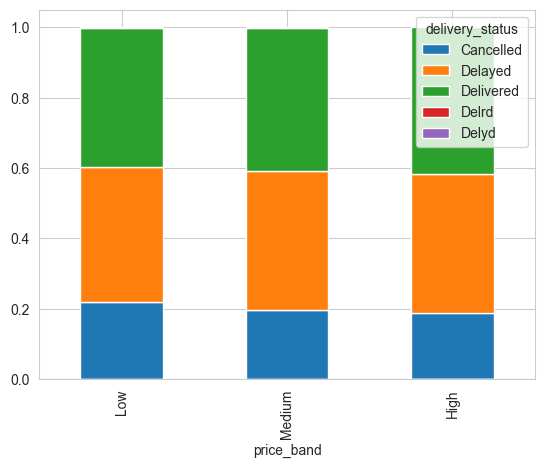

In [73]:
#delivery status by price band
pd.crosstab(
    merged_df['price_band'],
    merged_df['delivery_status'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.show()

In [74]:
#Business Question: Which product categories drive the most revenue, and in which regions?
category_region_revenue = (
    merged_df
    .groupby(['category', 'region_x'])['revenue']
    .sum()
    .reset_index()
    .sort_values('revenue', ascending=False)
)

category_region_revenue.head(10)

,category,region_x,revenue
1,Cleaning,East,19911.2990
3,Cleaning,South,18887.3650
2,Cleaning,North,18766.1035
4,Cleaning,West,18038.1790
0,Cleaning,Central,18018.8375
25,Storage,West,10014.4465
21,Storage,East,9498.1305
20,Storage,Central,9358.4750
24,Storage,South,9345.3590
13,Outdoors,South,9327.4165


In [75]:
#2. Do discounts lead to more items sold?
discount_quantity = (
    merged_df
    .groupby(pd.cut(merged_df['discount_applied'], bins=[0, 0.1, 0.2, 0.5, 1]))
    ['quantity']
    .mean()
)

discount_quantity

C:\Users\Salfil\AppData\Local\Temp\ipykernel_122920\3466056374.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.cut(merged_df['discount_applied'], bins=[0, 0.1, 0.2, 0.5, 1]))


discount_applied
(0.0, 0.1]    3.033697
(0.1, 0.2]    2.976791
(0.2, 0.5]         NaN
(0.5, 1.0]         NaN
Name: quantity, dtype: float64

In [76]:
merged_df[['discount_applied', 'quantity']].corr()

,discount_applied,quantity
discount_applied,1.000000,-0.009337
quantity,-0.009337,1.000000


In [77]:
#3. Which loyalty tier generates the most value?
loyalty_value = (
    merged_df
    .groupby('loyalty_tier')['revenue']
    .sum()
    .sort_values(ascending=False)
)

In [78]:
loyalty_value

loyalty_tier
Gold      1084.9690
Bronze     803.5460
Silver     777.3595
Name: revenue, dtype: float64

In [80]:
#4. Are certain regions struggling with delivery delays?
delay_rate = (
    merged_df
    .groupby('region_x')['is_late']
    .mean()
    .sort_values(ascending=False)
)

delay_rate

region_x
East       0.415282
North      0.392384
Central    0.389718
South      0.385906
West       0.369932
Nrth       0.000000
Name: is_late, dtype: float64

In [82]:
merged_df['region_x'] = merged_df['region_x'].replace({
    'nrth': 'North'
})

In [83]:
#5. Do customer signup patterns influence purchasing activity?
merged_df['signup_month'] = merged_df['signup_date'].dt.to_period('M')

signup_revenue = (
    merged_df
    .groupby('signup_month')['revenue']
    .mean()
)

signup_revenue

signup_month
2024-01     79.565245
2024-02     80.783761
2024-03     85.102170
2024-04     85.100190
2024-05     69.262780
2024-06     86.337520
2024-07     79.890557
2024-08     85.132995
2024-09     79.552288
2024-10     80.641125
2024-11     79.612704
2024-12     76.287453
2025-01     73.838373
2025-02     84.558971
2025-03     79.365537
2025-04     76.892199
2025-05     82.559965
2025-06     78.757171
2025-07     77.294857
2025-08     73.357727
2025-09     88.896793
2025-10     93.102500
2025-11    100.760245
2025-12     61.723933
Freq: M, Name: revenue, dtype: float64

In [85]:
#Step 2: Average time to first order by signup month

merged_df['days_from_signup'] = (
    merged_df['order_date'] - merged_df['signup_date']
).dt.days

In [86]:
signup_speed = (
    merged_df
    .groupby('signup_month')['days_from_signup']
    .mean()
)

signup_speed

signup_month
2024-01    570.285714
2024-02    498.294118
2024-03    461.055556
2024-04    432.428571
2024-05    364.312500
2024-06    365.931034
2024-07    342.500000
2024-08    325.450000
2024-09    266.784091
2024-10    244.440860
2024-11    210.728261
2024-12    167.536232
2025-01    148.902778
2025-02    113.602564
2025-03    101.580247
2025-04     68.134021
2025-05     63.810345
2025-06      7.671233
2025-07     24.700000
2025-08    -38.650000
2025-09    -54.588235
2025-10    -88.040000
2025-11   -142.888889
2025-12   -130.000000
Freq: M, Name: days_from_signup, dtype: float64

In [87]:
#purchase frequency by sign up month 
orders_per_customer = (
    merged_df
    .groupby(['signup_month', 'customer_id'])
    .size()
    .groupby('signup_month')
    .mean()
)

orders_per_customer

signup_month
2024-01    6.375000
2024-02    4.888889
2024-03    5.625000
2024-04    4.142857
2024-05    4.333333
2024-06    5.846154
2024-07    5.677419
2024-08    5.852941
2024-09    6.157895
2024-10    6.000000
2024-11    6.393939
2024-12    5.771429
2025-01    5.900000
2025-02    6.482759
2025-03    6.620690
2025-04    6.323529
2025-05    5.441176
2025-06    5.862069
2025-07    5.833333
2025-08    5.500000
2025-09    6.833333
2025-10    7.375000
2025-11    7.285714
2025-12    5.000000
Freq: M, dtype: float64

In [88]:
#Script 3: Total Customer Value (Much Stronger)
signup_ltv = (
    merged_df
    .groupby('signup_month')['revenue']
    .sum()
)

signup_ltv

signup_month
2024-01     4057.8275
2024-02     3554.4855
2024-03     3744.4955
2024-04     2467.9055
2024-05     1731.5695
2024-06     6561.6515
2024-07    13980.8475
2024-08    16941.4660
2024-09    18615.2355
2024-10    21289.2570
2024-11    16798.2805
2024-12    15410.0655
2025-01    13069.3920
2025-02    15981.6455
2025-03    15158.8175
2025-04    16454.9305
2025-05    15273.5935
2025-06    13388.7190
2025-07     2705.3200
2025-08     3227.7400
2025-09     3644.7685
2025-10     5493.0475
2025-11     5138.7725
2025-12     1851.7180
Freq: M, Name: revenue, dtype: float64

In [90]:
merged_df['region_x'].value_counts()

region_x
North      604
Central    603
East       602
South      596
West       592
Nrth         1
Name: count, dtype: int64

In [95]:
merged_df['region_x'] = merged_df['region_x'].replace({
    'Nrth': 'North'
})

In [96]:
merged_df['region_x'].value_counts()

region_x
North      605
Central    603
East       602
South      596
West       592
Name: count, dtype: int64

In [99]:
merged_df[merged_df['email'] == 'Unknown']

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region_x,discount_applied,product_name,category,launch_date,base_price,supplier_code,email,signup_date,gender,region_y,loyalty_tier,revenue,order_week,price_band,days_to_order,email_domain,is_late,signup_month,days_from_signup
29,O145341,C00470,P0024,1.0,29.47,NaT,Cancelled,Paypal,East,0.10,Storage Product 87,Storage,2025-02-24,26.33,S558,Unknown,2024-07-17,Femle,North,NaN,26.5230,<NA>,Medium,NaN,Unknown,False,2024-07,NaN
159,O333267,C00304,P0017,2.0,33.89,NaT,Delayed,Bank Transfer,Central,0.10,Personal Care Product 11,Personal Care,2024-12-16,16.46,S594,Unknown,2024-02-11,Male,East,NaN,61.0020,<NA>,High,NaN,Unknown,True,2024-02,NaN
270,O565535,C00088,P0022,3.0,12.83,NaT,Delayed,Paypal,Central,0.00,Cleaning Product 86,Cleaning,2024-04-10,19.77,S924,Unknown,2025-06-01,Male,West,NaN,38.4900,<NA>,Low,NaN,Unknown,True,2025-06,NaN
783,O195557,C00088,P0007,5.0,26.32,2025-09-06,Delayed,Paypal,East,0.15,Personal Care Product 64,Personal Care,2024-09-30,33.63,S379,Unknown,2025-06-01,Male,West,NaN,111.8600,36,Medium,341.0,Unknown,True,2025-06,97.0
878,O422085,C00340,P0017,1.0,36.99,NaT,Delayed,Credit Card,South,0.20,Personal Care Product 11,Personal Care,2024-12-16,16.46,S594,Unknown,2025-03-24,Male,Central,NaN,29.5920,<NA>,High,NaN,Unknown,True,2025-03,NaN
1013,O353488,C00088,P0018,2.0,10.74,2025-08-07,Delivered,Credit Card,East,0.10,Storage Product 37,Storage,2024-07-18,6.08,S767,Unknown,2025-06-01,Male,West,NaN,19.3320,32,Low,385.0,Unknown,False,2025-06,67.0
1225,O702019,C00148,P0022,1.0,34.28,2025-03-08,Delayed,Credit Card,Central,0.00,Cleaning Product 86,Cleaning,2024-04-10,19.77,S924,Unknown,2025-02-03,Male,West,NaN,34.2800,10,High,332.0,Unknown,True,2025-02,33.0
1228,O863028,C00376,P0007,5.0,35.67,2025-06-08,Delayed,Bank Transfer,East,0.20,Personal Care Product 64,Personal Care,2024-09-30,33.63,S379,Unknown,2024-12-07,Femle,South,NaN,142.6800,23,High,251.0,Unknown,True,2024-12,183.0
1243,O139220,C00376,P0012,2.0,13.29,NaT,Delayed,Bank Transfer,East,0.10,Cleaning Product 29,Cleaning,2025-04-19,14.67,S481,Unknown,2024-12-07,Femle,South,NaN,23.9220,<NA>,Low,NaN,Unknown,True,2024-12,NaN
1251,O915583,C00376,P0022,1.0,30.17,NaT,Delayed,Credit Card,North,0.20,Cleaning Product 86,Cleaning,2024-04-10,19.77,S924,Unknown,2024-12-07,Femle,South,NaN,24.1360,<NA>,High,NaN,Unknown,True,2024-12,NaN


In [100]:
merged_df['days_from_signup'] = merged_df['days_from_signup'].fillna('Unknown')

In [101]:
merged_df = merged_df[
    (merged_df['quantity'] >= 0) &
    (merged_df['unit_price'] >= 0) &
    (merged_df['discount_applied'] >= 0)
]

In [110]:
delivery_by_region = (
    merged_df
    .groupby('region_x')['is_late']
    .mean()  # proportion of orders that are late
    .reset_index()
)

delivery_by_region['late_percentage'] = delivery_by_region['is_late'] * 100
delivery_by_region = delivery_by_region.drop(columns='is_late')

delivery_by_region = delivery_by_region.sort_values('late_percentage', ascending=False)
delivery_by_region

delivery_by_region

,region_x,late_percentage
1,East,41.569282
2,North,39.173554
0,Central,39.036545
3,South,38.552189
4,West,36.993243


In [111]:
merged_df['loyalty_tier'].value_counts(dropna=False)

loyalty_tier
NaN       2962
Gold        13
Bronze      11
Silver       6
Name: count, dtype: int64

In [112]:
merged_df[['order_date', 'signup_date', 'launch_date']].dtypes

order_date     datetime64[ns]
signup_date    datetime64[ns]
launch_date    datetime64[ns]
dtype: object

In [113]:
sales_df['order_id'].duplicated().sum()
products_df['product_id'].duplicated().sum()
customers_df['customer_id'].duplicated().sum()

np.int64(0)

In [114]:
sales_df['order_id'].is_unique
products_df['product_id'].is_unique
customers_df['customer_id'].is_unique

True